In [130]:

# Import modules

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# Import functions
from cmdstanpy import CmdStanModel
from scipy.optimize import fsolve
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions

# Create stan folder if does not exists
if not os.path.exists("./stan"):
    os.mkdir("./stan")


STAN_PATH = r"C:\Users\Mohsen\.cmdstan\cmdstan-2.37.0"

from cmdstanpy import cmdstan_path, set_cmdstan_path
print(cmdstan_path())
set_cmdstan_path(STAN_PATH)
print(cmdstan_path())



C:\Users\Mohsen\.cmdstan\cmdstan-2.37.0
C:\Users\Mohsen\.cmdstan\cmdstan-2.37.0


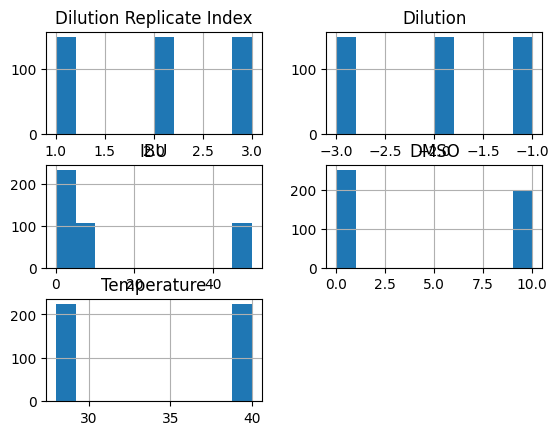

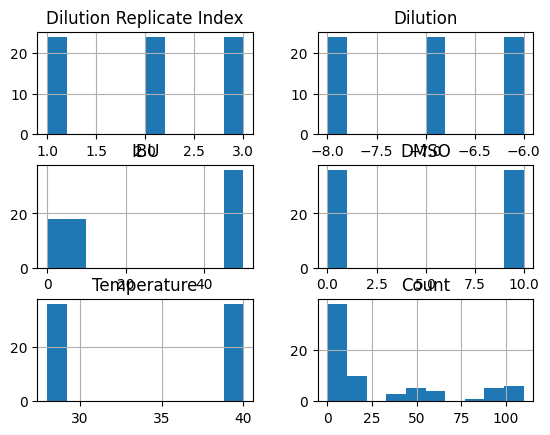

In [131]:


doners = pd.read_csv("../../data/data_donatori_eng.csv")
data = pd.read_csv("../../data/data_eng.csv")
data.hist()
doners.hist()
col_map = {"Experiment Index": "i", "Dilution Replicate Index": "k", "Control": "c", "Condition Replicate Index": "j" }
data.rename(columns=col_map, inplace=True)
doners.rename(columns=col_map, inplace=True)
data = data[~data['i'].astype(str).isin(['5','6','7', '8'])].copy()


In [132]:
data[data['i'] =='1']

,i,k,j,c,Dilution,IBU,DMSO,Temperature,Count
0,1,1,A,No,-1,6.25,0,28,TMTC
1,1,2,A,No,-1,6.25,0,28,TMTC
2,1,3,A,No,-1,6.25,0,28,TMTC
3,1,1,A,No,-2,6.25,0,28,36
4,1,2,A,No,-2,6.25,0,28,33
5,1,3,A,No,-2,6.25,0,28,30
6,1,1,A,No,-3,6.25,0,28,4
7,1,2,A,No,-3,6.25,0,28,6
8,1,3,A,No,-3,6.25,0,28,19
9,1,1,A,Yes,-1,0.00,0,28,TMTC


In [133]:
doners.head()

,i,k,Dilution,IBU,DMSO,Temperature,Count
0,1,1,-6,6.25,0,28,51
1,1,2,-6,6.25,0,28,48
2,1,3,-6,6.25,0,28,50
3,1,1,-7,6.25,0,28,7
4,1,2,-7,6.25,0,28,3


In [134]:
doners[doners['i'] == '1']

,i,k,Dilution,IBU,DMSO,Temperature,Count
0,1,1,-6,6.25,0,28,51
1,1,2,-6,6.25,0,28,48
2,1,3,-6,6.25,0,28,50
3,1,1,-7,6.25,0,28,7
4,1,2,-7,6.25,0,28,3
5,1,3,-7,6.25,0,28,4
6,1,1,-8,6.25,0,28,2
7,1,2,-8,6.25,0,28,0
8,1,3,-8,6.25,0,28,2


In [135]:

for col in data.columns:
    print(col)
    print(data[col].unique())

i
['1' '2' '3' '4' '9' '10' '5,6' '7,8']
k
[1 2 3]
j
['A' 'B' 'C']
c
['No' 'Yes']
Dilution
[-1 -2 -3]
IBU
[ 6.25  0.   50.  ]
DMSO
[ 0 10]
Temperature
[28 40]
Count
['TMTC' '36' '33' '30' '4' '6' '19' '27' '29' '37' '3' '7' '200' '214'
 '178' '5' '2' '1' '0' '157' '226' '225' '11' '108' '124' '98' '8' '10'
 '165' '195' '166' '16' '13' '14' '211' '233' '210' '12' '252' '242' '198'
 '15' '186' '148' '116' '122' '127' '9' '301' '309' '315' '229' '192'
 '230' '40' '26' '35' '60' '49' '179' '140' '160' '201' '139' '106' '199'
 '163' '22' '18' '17' '170' '145' '159' '196' '213' '271' '142' '177'
 '128' '81' '129' '86' '75' '71' '306' '297' '294' '202' '239' '32' '41'
 '25' '131' '141' '221' '263' '254' '90' '168' '132' '172' '164' '20']


In [136]:
data

,i,k,j,c,Dilution,IBU,DMSO,Temperature,Count
0,1,1,A,No,-1,6.25,0,28,TMTC
1,1,2,A,No,-1,6.25,0,28,TMTC
2,1,3,A,No,-1,6.25,0,28,TMTC
3,1,1,A,No,-2,6.25,0,28,36
4,1,2,A,No,-2,6.25,0,28,33
...,...,...,...,...,...,...,...,...,...
445,"7,8",2,C,Yes,-2,0.00,10,40,20
446,"7,8",3,C,Yes,-2,0.00,10,40,16
447,"7,8",1,C,Yes,-3,0.00,10,40,0
448,"7,8",2,C,Yes,-3,0.00,10,40,1


In [137]:
for col in doners.columns:
    print(col)
    print(doners[col].unique())

i
['1' '2' '3' '4' '5,6' '7,8' '9' '10']
k
[1 2 3]
Dilution
[-6 -7 -8]
IBU
[ 6.25 50.    0.  ]
DMSO
[ 0 10]
Temperature
[28 40]
Count
[ 51  48  50   7   3   4   2   0 109 110  96  10  12  56  54  83  89  91
  15   1   5  61  43  33   6  55  40   8   9  90 106 102  17  16  13]


In [138]:
print(len(doners))
print(len(data))

72
342


In [139]:
doners

,i,k,Dilution,IBU,DMSO,Temperature,Count
0,1,1,-6,6.25,0,28,51
1,1,2,-6,6.25,0,28,48
2,1,3,-6,6.25,0,28,50
3,1,1,-7,6.25,0,28,7
4,1,2,-7,6.25,0,28,3
...,...,...,...,...,...,...,...
67,10,2,-7,0.00,10,40,16
68,10,3,-7,0.00,10,40,13
69,10,1,-8,0.00,10,40,5
70,10,2,-8,0.00,10,40,6


In [140]:
print(len(data)/len(doners))

4.75


In [141]:

rows = []
temp_i_index = '1'
temp_k_index = 1
temp_doners_t = pd.DataFrame()
data_frames = {}
for n in doners['i'].unique():
    data_frames[n] = {}
    for nn in doners[doners['i'] == n]['k'].unique():
        temp_doners = doners[(doners['i'] == n) & (doners['k'] == nn)]
        temp_data = data[(data['i'] == n) & (data['k'] == nn)]
        d_len = len(temp_doners)
        x_len = len(temp_data)
        ratio = x_len / d_len if d_len > 0 else float('nan')
        rows.append({'i': n, 'k': nn, 'doners_len': d_len, 'data_len': x_len, 'ratio': ratio})
        data_frames[n][int(nn)] = (temp_doners.copy(), temp_data.copy())
        if (n == temp_i_index) and (nn == temp_k_index):
            print("lkdsj")
            temp_doners_t = temp_doners.copy()
            
        
        

ratios_df = pd.DataFrame(rows)
print("Ratios for each (i,k):")
print(ratios_df)

lkdsj
Ratios for each (i,k):
      i  k  doners_len  data_len  ratio
0     1  1           3        18    6.0
1     1  2           3        18    6.0
2     1  3           3        18    6.0
3     2  1           3        18    6.0
4     2  2           3        18    6.0
5     2  3           3        18    6.0
6     3  1           3        18    6.0
7     3  2           3        18    6.0
8     3  3           3        18    6.0
9     4  1           3        18    6.0
10    4  2           3        18    6.0
11    4  3           3        18    6.0
12  5,6  1           3         9    3.0
13  5,6  2           3         9    3.0
14  5,6  3           3         9    3.0
15  7,8  1           3         9    3.0
16  7,8  2           3         9    3.0
17  7,8  3           3         9    3.0
18    9  1           3        12    4.0
19    9  2           3        12    4.0
20    9  3           3        12    4.0
21   10  1           3        12    4.0
22   10  2           3        12    4.0
23   10  3 

In [142]:

rows = []
temp_i_index = '1'
temp_k_index = 1
temp_doners_t = pd.DataFrame()
data_frames = {}
for n in doners['i'].unique():
    temp_doners = doners[(doners['i'] == n)]
    temp_data = data[(data['i'] == n)]
    d_len = len(temp_doners)
    x_len = len(temp_data)
    ratio = x_len / d_len if d_len > 0 else float('nan')
    rows.append({'i': n, 'k': nn, 'doners_len': d_len, 'data_len': x_len, 'ratio': ratio})
    data_frames[n] = (temp_doners.copy(), temp_data.copy())
            
        
        

ratios_df = pd.DataFrame(rows)
print("Ratios for each (i,k):")
print(ratios_df)

Ratios for each (i,k):
     i  k  doners_len  data_len  ratio
0    1  3           9        54    6.0
1    2  3           9        54    6.0
2    3  3           9        54    6.0
3    4  3           9        54    6.0
4  5,6  3           9        27    3.0
5  7,8  3           9        27    3.0
6    9  3           9        36    4.0
7   10  3           9        36    4.0


486/63

## Frequentist Data Analysis



In [143]:
doners = pd.read_csv("../../data/data_donatori_eng.csv")
data = pd.read_csv("../../data/data_eng.csv")
col_map = {"Experiment Index": "i", "Dilution Replicate Index": "k", "Control": "c", "Condition Replicate Index": "j" }
data.rename(columns=col_map, inplace=True)
doners.rename(columns=col_map, inplace=True)
data = data[~data['i'].astype(str).isin(['5','6','7', '8'])].copy()
# where count is equal to 'TMTC' we set it to 0 
TMTC = 100000000
data['Count'] = data['Count'].replace('TMTC', TMTC)

data['c'] = data['c'].replace('No', -1)
data['c'] = data['c'].replace('Yes', 1)

data['j'] = data['j'].replace('A', 0)
data['j'] = data['j'].replace('B', 1)
data['j'] = data['j'].replace('C', 2)


for col in data.columns:
    if col == "i":
        continue
    data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0)


C:\Users\Mohsen\AppData\Local\Temp\ipykernel_12272\4270534846.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['c'] = data['c'].replace('Yes', 1)
C:\Users\Mohsen\AppData\Local\Temp\ipykernel_12272\4270534846.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['j'] = data['j'].replace('C', 2)


In [144]:
data.head()

,i,k,j,c,Dilution,IBU,DMSO,Temperature,Count
0,1,1,0,-1,-1,6.25,0,28,100000000
1,1,2,0,-1,-1,6.25,0,28,100000000
2,1,3,0,-1,-1,6.25,0,28,100000000
3,1,1,0,-1,-2,6.25,0,28,36
4,1,2,0,-1,-2,6.25,0,28,33


In [145]:
data['count_final'] = data["Count"] * (10 ** (-data['Dilution']))
data_f = data[['i', 'k', 'j', 'c', 'count_final', 'IBU', 'DMSO', 'Temperature']].copy()

In [146]:
data_f['c'].unique()

array([-1,  1])


Group c == -1 (n=144)
Pearson r (r, p):
  IBU: r=-0.1702, p=0.04142
  DMSO: r=-0.1491, p=0.07454
  Temperature: r=-0.2582, p=0.001781

Spearman rho (rho, p):
  IBU: rho=0.0363, p=0.6657
  DMSO: rho=-0.3194, p=9.532e-05
  Temperature: rho=-0.2511, p=0.002395

Group c == 1 (n=198)
Pearson r (r, p):
  IBU: r=nan, p=nan
  DMSO: r=0.3515, p=3.827e-07
  Temperature: r=-0.1325, p=0.06286

Spearman rho (rho, p):
  IBU: rho=nan, p=nan
  DMSO: rho=0.0632, p=0.3764
  Temperature: rho=-0.1544, p=0.02989


C:\Users\Mohsen\AppData\Local\Temp\ipykernel_12272\1659864821.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson[c] = stats.pearsonr(sub['count_final'], sub[c])
C:\Users\Mohsen\AppData\Local\Temp\ipykernel_12272\1659864821.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  res = stats.spearmanr(sub['count_final'], sub[c])


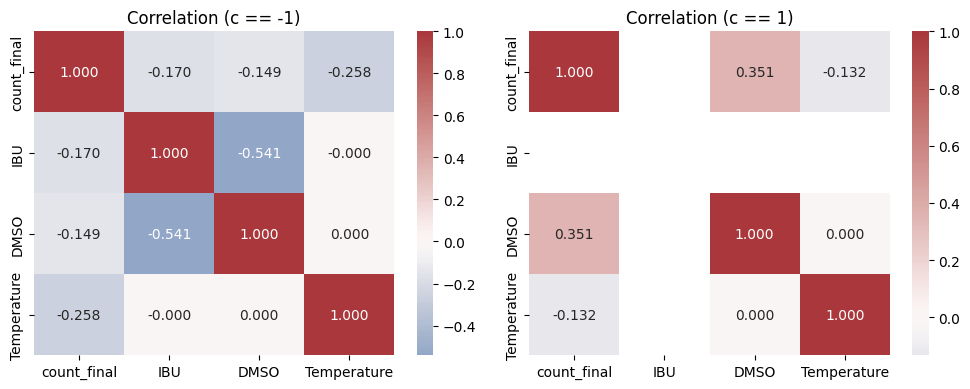

In [147]:
cols = ['IBU', 'DMSO', 'Temperature']  
for group in data_f['c'].unique():
    sub = data[['count_final'] + cols + ['c']].dropna()
    sub = sub[sub['c'] == group]
    print(f"\nGroup c == {group} (n={len(sub)})")

    pearson = {}
    spearman = {}

    for c in cols:
        try:
            pearson[c] = stats.pearsonr(sub['count_final'], sub[c])
        except Exception:
            pearson[c] = (np.nan, np.nan)
        try:
            res = stats.spearmanr(sub['count_final'], sub[c])
            rho, p = (res.correlation, res.pvalue) if hasattr(res, 'correlation') else (res[0], res[1])
            spearman[c] = (rho, p)
        except Exception:
            spearman[c] = (np.nan, np.nan)

    print("Pearson r (r, p):")
    for c, (r, p) in pearson.items():
        print(f"  {c}: r={r:.4f}, p={p:.4g}")

    print("\nSpearman rho (rho, p):")
    for c, (rho, p) in spearman.items():
        print(f"  {c}: rho={rho:.4f}, p={p:.4g}")

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
for ax, group in zip(axs, data_f['c'].unique()):
    sub = data[['count_final'] + cols + ['c']].dropna()
    sub = sub[sub['c'] == group]
    corr = sub[['count_final'] + cols].corr()
    sns.heatmap(corr, annot=True, fmt=".3f", cmap='vlag', center=0, ax=ax)
    ax.set_title(f'Correlation (c == {group})')
plt.tight_layout()
plt.show()

## Dimenstion Analysis
we assume that the IBU, DMSO, Temperature, and c, and final_count are the dimensions. 
we do multiple dimension reduction to better underestand the data.



=== PCA for c=-1, n_components=2 ===
Explained variance ratio: [0.39213046 0.32407505]
Loadings:
IBU: [-0.62577657 -0.37520479]
DMSO: [0.72448393 0.02977141]
Temperature: [ 0.12145501 -0.61540339]
log_count_final: [-0.26225064  0.69254148]

=== PCA for c=-1, n_components=3 ===
Explained variance ratio: [0.39213046 0.32407505 0.20643261]
Loadings:
IBU: [-0.62577657 -0.37520479 -0.33683359]
DMSO: [ 0.72448393  0.02977141 -0.23626161]
Temperature: [ 0.12145501 -0.61540339  0.76004116]
log_count_final: [-0.26225064  0.69254148  0.5030517 ]

=== PCA for c=1, n_components=2 ===
Explained variance ratio: [0.42088447 0.33333333]
Loadings:
IBU: [0. 0.]
DMSO: [0.55759219 0.61496496]
Temperature: [-0.43484589  0.78855444]
log_count_final: [ 7.07106781e-01 -5.55111512e-16]

=== PCA for c=1, n_components=3 ===
Explained variance ratio: [0.42088447 0.33333333 0.24578219]
Loadings:
IBU: [0. 0. 0.]
DMSO: [ 0.55759219  0.61496496 -0.55759219]
Temperature: [-0.43484589  0.78855444  0.43484589]
log_coun

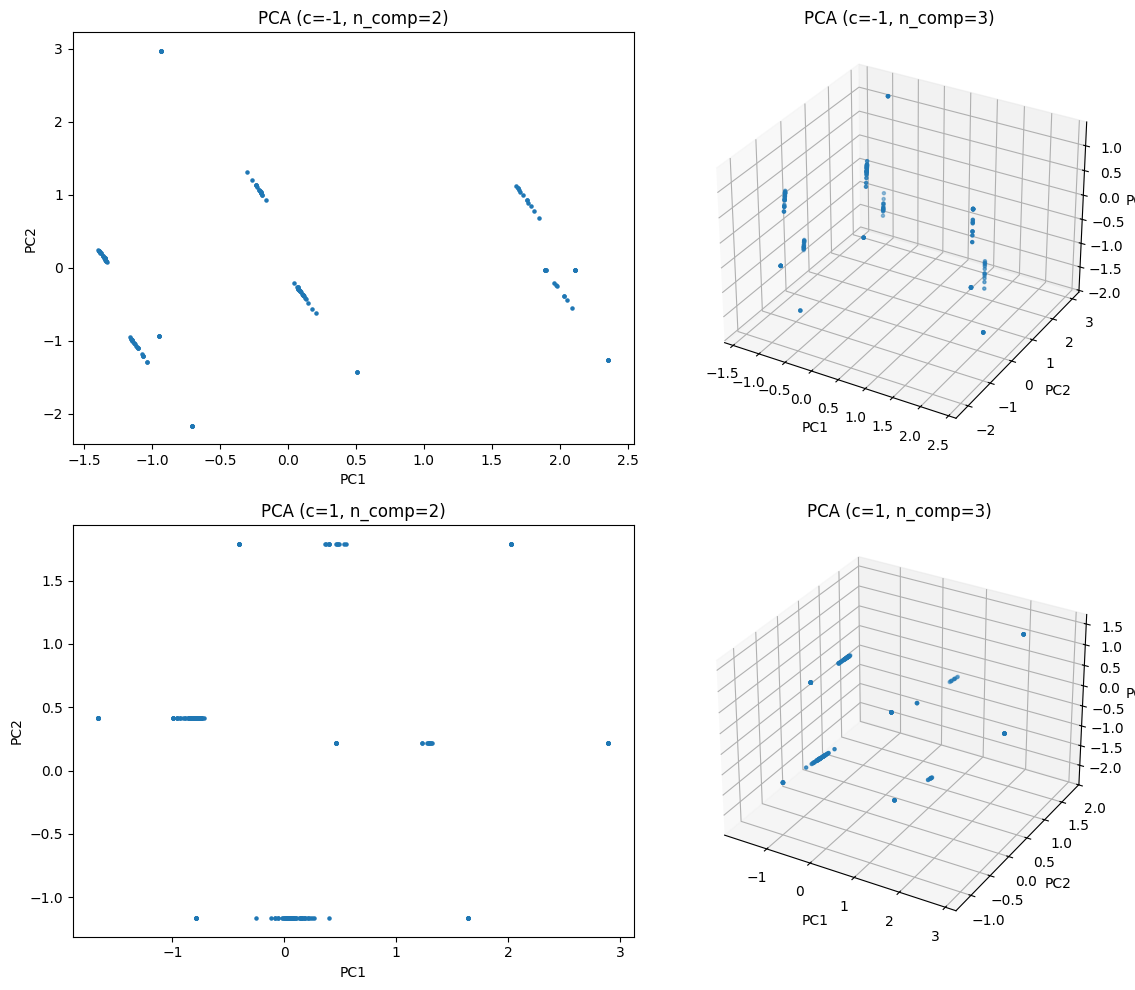

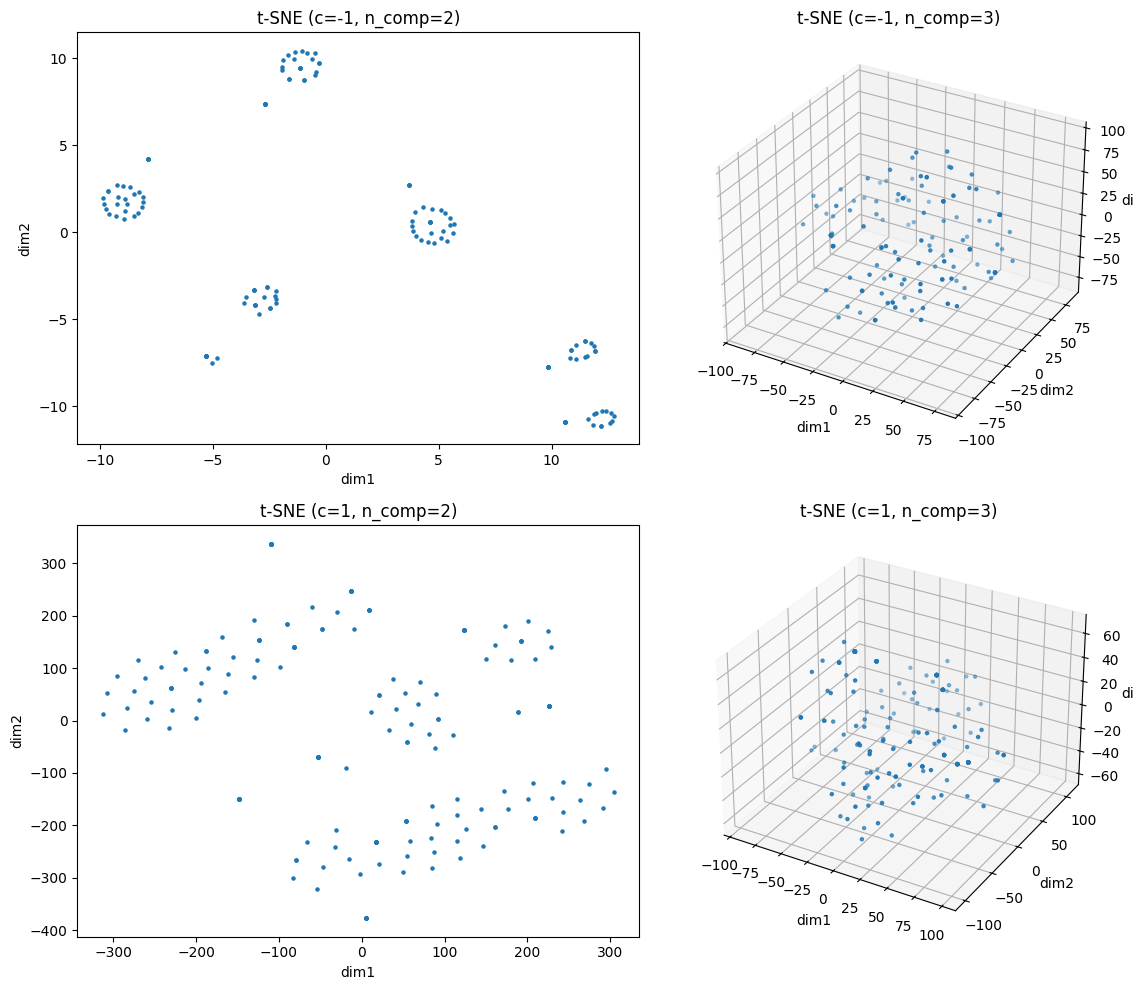

In [148]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

data_f["log_count_final"] = np.log10(data_f["count_final"] + 1)

features = ["IBU", "DMSO", "Temperature", "log_count_final"]
c_values = [-1, 1]
n_components_list = [2, 3]


fig_pca = plt.figure(figsize=(12, 10))
plot_idx = 1

for c_val in c_values:
    sub = data_f[data_f["c"] == c_val]
    X = sub[features].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    for n_comp in n_components_list:
       
        if n_comp == 2:
            ax = fig_pca.add_subplot(2, 2, plot_idx)
        else:
            ax = fig_pca.add_subplot(2, 2, plot_idx, projection="3d")
        plot_idx += 1

        pca = PCA(n_components=n_comp)
        X_pca = pca.fit_transform(X_scaled)

        print(f"\n=== PCA for c={c_val}, n_components={n_comp} ===")
        print("Explained variance ratio:", pca.explained_variance_ratio_)
        loadings = pca.components_.T
        print("Loadings:")
        for feat, loading in zip(features, loadings):
            print(f"{feat}: {loading}")

        if n_comp == 2:
            ax.scatter(X_pca[:, 0], X_pca[:, 1], s=5)
            ax.set_xlabel("PC1")
            ax.set_ylabel("PC2")
        else:
            ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], s=5)
            ax.set_xlabel("PC1")
            ax.set_ylabel("PC2")
            ax.set_zlabel("PC3")

        ax.set_title(f"PCA (c={c_val}, n_comp={n_comp})")

fig_pca.tight_layout()
plt.show()


fig_tsne = plt.figure(figsize=(12, 10))
plot_idx = 1

for c_val in c_values:
    sub = data_f[data_f["c"] == c_val]
    X = sub[features].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    for n_comp in n_components_list:
        if n_comp == 2:
            ax = fig_tsne.add_subplot(2, 2, plot_idx)
        else:
            ax = fig_tsne.add_subplot(2, 2, plot_idx, projection="3d")
        plot_idx += 1

        tsne = TSNE(
            n_components=n_comp,
            perplexity=30,
            learning_rate="auto",
            init="pca",
            random_state=0,
        )
        X_tsne = tsne.fit_transform(X_scaled)

        if n_comp == 2:
            ax.scatter(X_tsne[:, 0], X_tsne[:, 1], s=5)
            ax.set_xlabel("dim1")
            ax.set_ylabel("dim2")
        else:
            ax.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], s=5)
            ax.set_xlabel("dim1")
            ax.set_ylabel("dim2")
            ax.set_zlabel("dim3")

        ax.set_title(f"t-SNE (c={c_val}, n_comp={n_comp})")

fig_tsne.tight_layout()
plt.show()


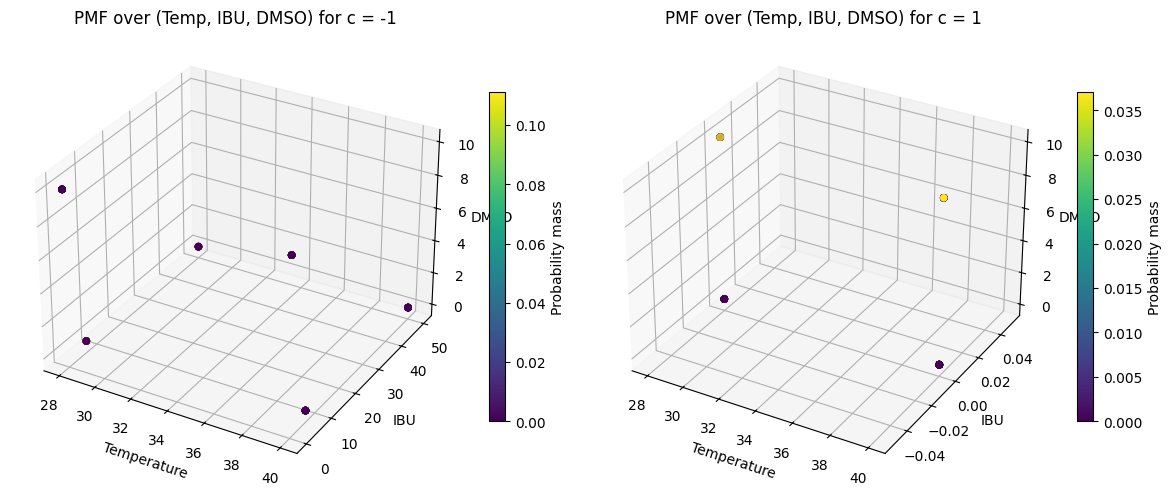

In [149]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

features_3d = ["Temperature", "IBU", "DMSO"]
c_values = [-1, 1]

fig = plt.figure(figsize=(12, 5))

for idx, c_val in enumerate(c_values, start=1):
    sub = data_f[data_f["c"] == c_val].copy()

 
    X3 = sub[features_3d].values  

    counts = sub["count_final"].astype(float).values
    total = counts.sum()
    if total == 0:
        raise ValueError(f"Total count is zero for c = {c_val}")
    pmf = counts / total  

    ax = fig.add_subplot(1, 2, idx, projection="3d")

    sc = ax.scatter(
        X3[:, 0],  
        X3[:, 1], 
        X3[:, 2], 
        c=pmf,
        s=20,
        cmap="viridis"
    )

    ax.set_xlabel("Temperature")
    ax.set_ylabel("IBU")
    ax.set_zlabel("DMSO")
    ax.set_title(f"PMF over (Temp, IBU, DMSO) for c = {c_val}")

    cbar = fig.colorbar(sc, ax=ax, shrink=0.7)
    cbar.set_label("Probability mass")

plt.tight_layout()
plt.show()


e:\amirhossein\Polimi\052499_BAYSIAN STATISTICS\Progetto_Bayesian_Statistics\.venv\Lib\site-packages\sklearn\neighbors\_kde.py:274: RuntimeWarning: divide by zero encountered in log
  log_density = self.tree_.kernel_density(
e:\amirhossein\Polimi\052499_BAYSIAN STATISTICS\Progetto_Bayesian_Statistics\.venv\Lib\site-packages\sklearn\neighbors\_kde.py:274: RuntimeWarning: divide by zero encountered in log
  log_density = self.tree_.kernel_density(


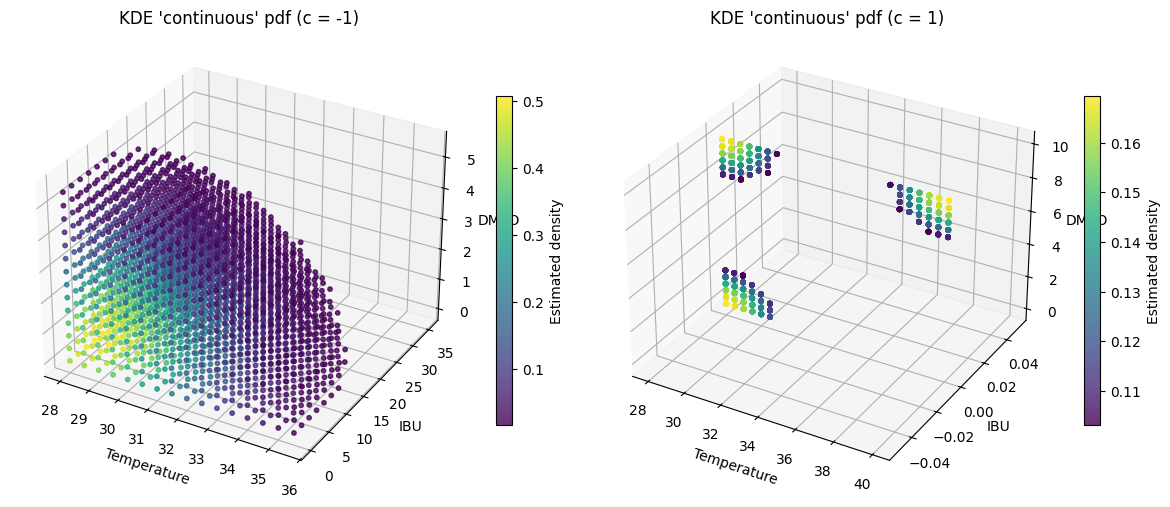

In [150]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler

features_3d = ["Temperature", "IBU", "DMSO"]
c_values = [-1, 1]

fig = plt.figure(figsize=(12, 5))

for idx, c_val in enumerate(c_values, start=1):
    sub = data_f[data_f["c"] == c_val].copy()
    if len(sub) == 0:
        print(f"No data for c = {c_val}")
        continue

    
    X_raw = sub[features_3d].values  # (N, 3)
    counts = sub["count_final"].astype(float).values

    
    counts[counts < 0] = 0.0
    if counts.sum() == 0:
        print(f"All counts zero for c = {c_val}")
        continue

   
    scaler = StandardScaler()
    X = scaler.fit_transform(X_raw)

    kde = KernelDensity(bandwidth=0.5, kernel="gaussian")
    kde.fit(X, sample_weight=counts)
    grid_size = 25  
    T_lin = np.linspace(X_raw[:, 0].min(), X_raw[:, 0].max(), grid_size)
    I_lin = np.linspace(X_raw[:, 1].min(), X_raw[:, 1].max(), grid_size)
    D_lin = np.linspace(X_raw[:, 2].min(), X_raw[:, 2].max(), grid_size)

    T_grid, I_grid, D_grid = np.meshgrid(T_lin, I_lin, D_lin, indexing="ij")
    grid_points_orig = np.vstack([
        T_grid.ravel(),
        I_grid.ravel(),
        D_grid.ravel()
    ]).T  

    grid_points_scaled = scaler.transform(grid_points_orig)
    log_dens = kde.score_samples(grid_points_scaled)
    dens = np.exp(log_dens)  

   
    keep_quantile = 0.85  
    thr = np.quantile(dens, keep_quantile)
    mask = dens >= thr

    pts = grid_points_orig[mask]
    dens_sel = dens[mask]

    ax = fig.add_subplot(1, 2, idx, projection="3d")

    sc = ax.scatter(
        pts[:, 0],  
        pts[:, 1],  
        pts[:, 2],  
        c=dens_sel,
        s=10,
        cmap="viridis",
        alpha=0.8,
    )

    ax.set_xlabel("Temperature")
    ax.set_ylabel("IBU")
    ax.set_zlabel("DMSO")
    ax.set_title(f"KDE 'continuous' pdf (c = {c_val})")

    cbar = fig.colorbar(sc, ax=ax, shrink=0.7)
    cbar.set_label("Estimated density")

plt.tight_layout()
plt.show()



=== PCA 2D for c=-1 ===
Explained variance ratio: [0.51358586 0.33333333]
Components (rows = PC1, PC2; cols = Temp, IBU, DMSO):
[[-0.          0.70710678 -0.70710678]
 [ 1.          0.          0.        ]]


e:\amirhossein\Polimi\052499_BAYSIAN STATISTICS\Progetto_Bayesian_Statistics\.venv\Lib\site-packages\sklearn\neighbors\_kde.py:274: RuntimeWarning: divide by zero encountered in log
  log_density = self.tree_.kernel_density(



=== PCA 2D for c=1 ===
Explained variance ratio: [0.5 0.5]
Components (rows = PC1, PC2; cols = Temp, IBU, DMSO):
[[ 1.  0.  0.]
 [-0. -0.  1.]]


e:\amirhossein\Polimi\052499_BAYSIAN STATISTICS\Progetto_Bayesian_Statistics\.venv\Lib\site-packages\sklearn\neighbors\_kde.py:274: RuntimeWarning: divide by zero encountered in log
  log_density = self.tree_.kernel_density(


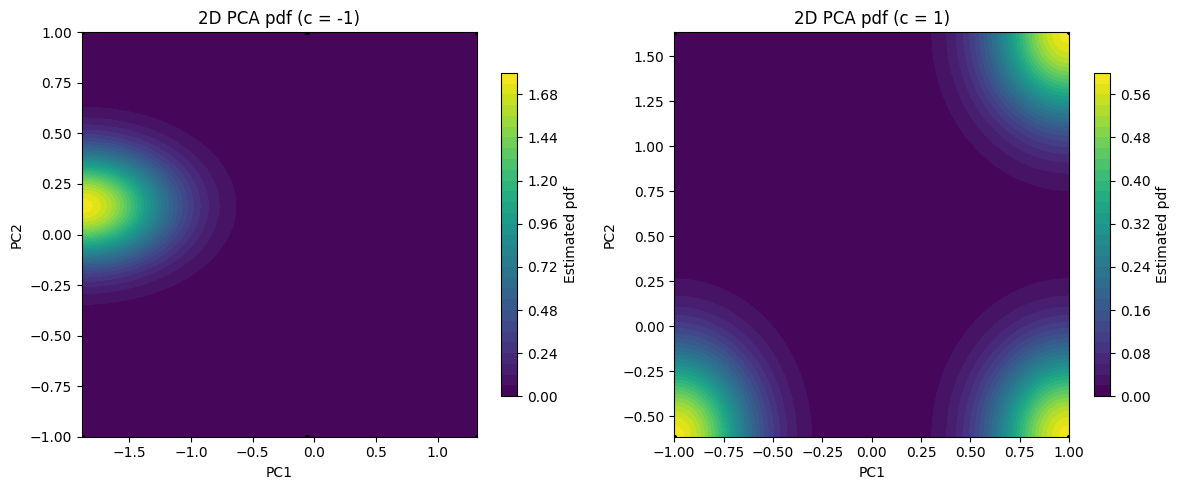

In [151]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KernelDensity

features_3d = ["Temperature", "IBU", "DMSO"]
c_values = [-1, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, c_val in enumerate(c_values):
    sub = data_f[data_f["c"] == c_val].copy()
    if len(sub) == 0:
        print(f"No data for c = {c_val}")
        continue

    X_raw = sub[features_3d].values  
    counts = sub["count_final"].astype(float).values
    counts[counts < 0] = 0.0
    if counts.sum() == 0:
        print(f"All counts zero for c = {c_val}")
        continue

 
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    pca_2d = PCA(n_components=2)
    X_pca2 = pca_2d.fit_transform(X_scaled)  

    print(f"\n=== PCA 2D for c={c_val} ===")
    print("Explained variance ratio:", pca_2d.explained_variance_ratio_)
    print("Components (rows = PC1, PC2; cols = Temp, IBU, DMSO):")
    print(pca_2d.components_)

    kde2d = KernelDensity(kernel="gaussian", bandwidth=0.3)  
    kde2d.fit(X_pca2, sample_weight=counts)

    grid_size = 150
    x_lin = np.linspace(X_pca2[:, 0].min(), X_pca2[:, 0].max(), grid_size)
    y_lin = np.linspace(X_pca2[:, 1].min(), X_pca2[:, 1].max(), grid_size)
    Xg, Yg = np.meshgrid(x_lin, y_lin)
    grid_points = np.vstack([Xg.ravel(), Yg.ravel()]).T  

    log_dens = kde2d.score_samples(grid_points)
    dens = np.exp(log_dens).reshape(grid_size, grid_size)

    ax = axes[idx]


    cf = ax.contourf(
        x_lin,
        y_lin,
        dens.T,        
        levels=30
    )

  
    ax.scatter(
        X_pca2[:, 0],
        X_pca2[:, 1],
        s=5,
        c="k",
        alpha=0.3
    )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"2D PCA pdf (c = {c_val})")

    cbar = fig.colorbar(cf, ax=ax, shrink=0.8)
    cbar.set_label("Estimated pdf")

plt.tight_layout()
plt.show()



=== PCA 1D for c=-1 ===
Explained variance ratio: [0.51358586]
Component (weights on Temp, IBU, DMSO):
[-0.          0.70710678 -0.70710678]

=== PCA 1D for c=1 ===
Explained variance ratio: [0.5]
Component (weights on Temp, IBU, DMSO):
[1. 0. 0.]


e:\amirhossein\Polimi\052499_BAYSIAN STATISTICS\Progetto_Bayesian_Statistics\.venv\Lib\site-packages\sklearn\neighbors\_kde.py:274: RuntimeWarning: divide by zero encountered in log
  log_density = self.tree_.kernel_density(
e:\amirhossein\Polimi\052499_BAYSIAN STATISTICS\Progetto_Bayesian_Statistics\.venv\Lib\site-packages\sklearn\neighbors\_kde.py:274: RuntimeWarning: divide by zero encountered in log
  log_density = self.tree_.kernel_density(


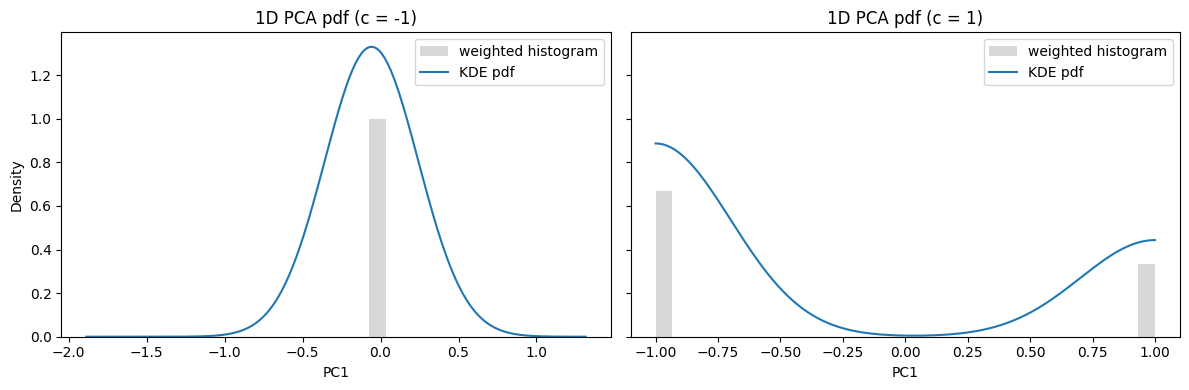

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for idx, c_val in enumerate(c_values):
    sub = data_f[data_f["c"] == c_val].copy()
    if len(sub) == 0:
        print(f"No data for c = {c_val}")
        continue

    X_raw = sub[features_3d].values
    counts = sub["count_final"].astype(float).values
    counts[counts < 0] = 0.0
    if counts.sum() == 0:
        print(f"All counts zero for c = {c_val}")
        continue

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    
    pca_1d = PCA(n_components=1)
    X_pca1 = pca_1d.fit_transform(X_scaled).ravel() 
    print(f"\n=== PCA 1D for c={c_val} ===")
    print("Explained variance ratio:", pca_1d.explained_variance_ratio_)
    print("Component (weights on Temp, IBU, DMSO):")
    print(pca_1d.components_[0])

    kde1d = KernelDensity(kernel="gaussian", bandwidth=0.3)
    kde1d.fit(X_pca1[:, None], sample_weight=counts)

    x_lin = np.linspace(X_pca1.min(), X_pca1.max(), 400)[:, None]
    log_dens_1d = kde1d.score_samples(x_lin)
    dens_1d = np.exp(log_dens_1d)

    ax = axes[idx]

    ax.hist(
        X_pca1,
        bins=30,
        weights=counts / counts.sum(),
        density=False,
        alpha=0.3,
        color="gray",
        label="weighted histogram"
    )

    ax.plot(x_lin[:, 0], dens_1d, label="KDE pdf")

    ax.set_xlabel("PC1")
    if idx == 0:
        ax.set_ylabel("Density")
    ax.set_title(f"1D PCA pdf (c = {c_val})")
    ax.legend()

plt.tight_layout()
plt.show()



=== PCA 2D for c=-1 ===
Explained variance ratio: [0.51358586 0.33333333]
Components (rows = PC1, PC2; cols = Temp, IBU, DMSO):
[[-0.          0.70710678 -0.70710678]
 [ 1.          0.          0.        ]]


e:\amirhossein\Polimi\052499_BAYSIAN STATISTICS\Progetto_Bayesian_Statistics\.venv\Lib\site-packages\sklearn\neighbors\_kde.py:274: RuntimeWarning: divide by zero encountered in log
  log_density = self.tree_.kernel_density(



=== PCA 2D for c=1 ===
Explained variance ratio: [0.5 0.5]
Components (rows = PC1, PC2; cols = Temp, IBU, DMSO):
[[ 1.  0.  0.]
 [-0. -0.  1.]]


e:\amirhossein\Polimi\052499_BAYSIAN STATISTICS\Progetto_Bayesian_Statistics\.venv\Lib\site-packages\sklearn\neighbors\_kde.py:274: RuntimeWarning: divide by zero encountered in log
  log_density = self.tree_.kernel_density(


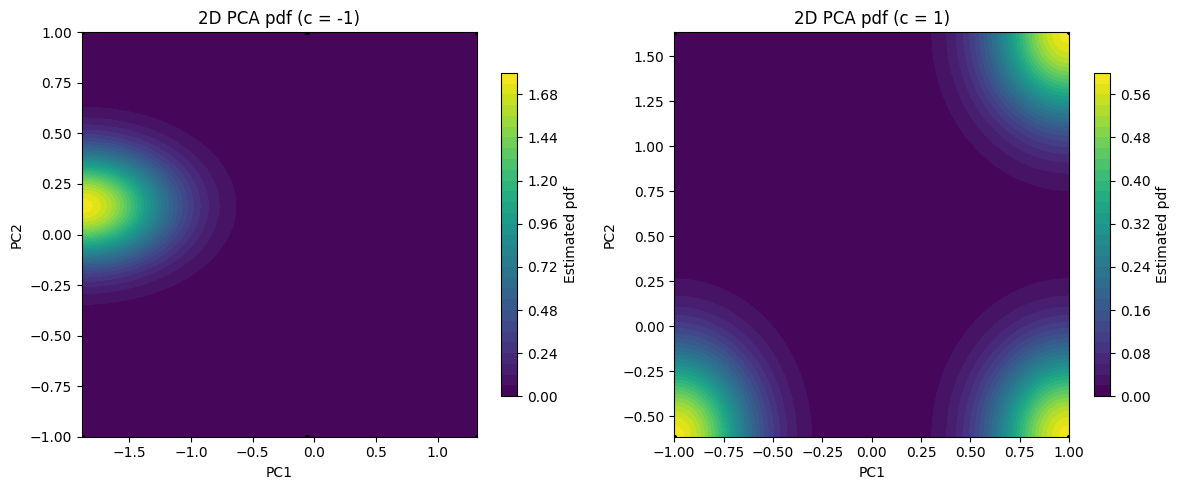

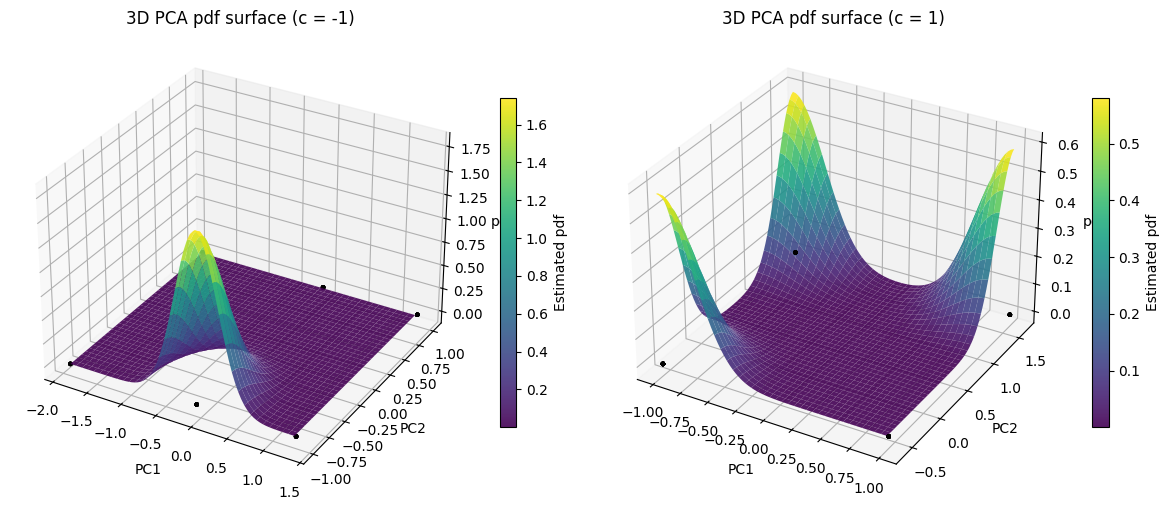

In [153]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KernelDensity

features_3d = ["Temperature", "IBU", "DMSO"]
c_values = [-1, 1]


fig2d, axes2d = plt.subplots(1, 2, figsize=(12, 5))

fig3d = plt.figure(figsize=(12, 5))

for idx, c_val in enumerate(c_values):
    sub = data_f[data_f["c"] == c_val].copy()
    if len(sub) == 0:
        print(f"No data for c = {c_val}")
        continue

    X_raw = sub[features_3d].values  
    counts = sub["count_final"].astype(float).values
    counts[counts < 0] = 0.0
    if counts.sum() == 0:
        print(f"All counts zero for c = {c_val}")
        continue


    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)


    pca_2d = PCA(n_components=2)
    X_pca2 = pca_2d.fit_transform(X_scaled) 

    print(f"\n=== PCA 2D for c={c_val} ===")
    print("Explained variance ratio:", pca_2d.explained_variance_ratio_)
    print("Components (rows = PC1, PC2; cols = Temp, IBU, DMSO):")
    print(pca_2d.components_)


    kde2d = KernelDensity(kernel="gaussian", bandwidth=0.3)  
    kde2d.fit(X_pca2, sample_weight=counts)


    grid_size = 150
    x_lin = np.linspace(X_pca2[:, 0].min(), X_pca2[:, 0].max(), grid_size)
    y_lin = np.linspace(X_pca2[:, 1].min(), X_pca2[:, 1].max(), grid_size)
    Xg, Yg = np.meshgrid(x_lin, y_lin)        
    grid_points = np.vstack([Xg.ravel(), Yg.ravel()]).T  

    log_dens = kde2d.score_samples(grid_points)
    dens = np.exp(log_dens).reshape(grid_size, grid_size)  

    ax2d = axes2d[idx]

    cf = ax2d.contourf(
        x_lin,
        y_lin,
        dens.T,         
        levels=30
    )

    ax2d.scatter(
        X_pca2[:, 0],
        X_pca2[:, 1],
        s=5,
        c="k",
        alpha=0.3
    )

    ax2d.set_xlabel("PC1")
    ax2d.set_ylabel("PC2")
    ax2d.set_title(f"2D PCA pdf (c = {c_val})")

    cbar2d = fig2d.colorbar(cf, ax=ax2d, shrink=0.8)
    cbar2d.set_label("Estimated pdf")


    ax3d = fig3d.add_subplot(1, 2, idx + 1, projection="3d")

   
    step = 2 
    surf = ax3d.plot_surface(
        Xg[::step, ::step],
        Yg[::step, ::step],
        dens[::step, ::step],
        cmap="viridis",
        edgecolor="none",
        alpha=0.9,
    )

   
    ax3d.scatter(
        X_pca2[:, 0],
        X_pca2[:, 1],
        np.zeros_like(X_pca2[:, 0]),
        c="k",
        s=5,
        alpha=0.4,
    )

    ax3d.set_xlabel("PC1")
    ax3d.set_ylabel("PC2")
    ax3d.set_zlabel("pdf")
    ax3d.set_title(f"3D PCA pdf surface (c = {c_val})")

    cbar3d = fig3d.colorbar(surf, ax=ax3d, shrink=0.7)
    cbar3d.set_label("Estimated pdf")

fig2d.tight_layout()
fig3d.tight_layout()
plt.show()


# Baysian Analysis
